# Project Title: Speech Emotion Recognition (en)

**About the dataset**: 

Context:

Speech is the most natural way of expressing ourselves as humans. It is only natural then to extend this communication medium to computer applications. We define speech emotion recognition (SER) systems as a collection of methodologies that process and classify speech signals to detect the embedded emotions. SER is not a new field, it has been around for over two decades, and has regained attention thanks to the recent advancements. These novel studies make use of the advances in all fields of computing and technology, making it necessary to have an update on the current methodologies and techniques that make SER possible. We have identified and discussed distinct areas of SER, provided a detailed survey of current literature of each, and also listed the current challenges.

Content:

Here 4 most popular datasets in English: Crema, Ravdess, Savee and Tess. Each of them contains audio in .wav format with some main labels.

Ravdess:

Here is the filename identifiers as per the official RAVDESS website:

Modality (01 = full-AV, 02 = video-only, 03 = audio-only).
Vocal channel (01 = speech, 02 = song).
Emotion (01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised).
Emotional intensity (01 = normal, 02 = strong). NOTE: There is no strong intensity for the 'neutral' emotion.
Statement (01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door").
Repetition (01 = 1st repetition, 02 = 2nd repetition).
Actor (01 to 24. Odd numbered actors are male, even numbered actors are female).
So, here's an example of an audio filename. 02-01-06-01-02-01-12.wav This means the meta data for the audio file is:

Video-only (02)
Speech (01)
Fearful (06)
Normal intensity (01)
Statement "dogs" (02)
1st Repetition (01)
12th Actor (12) - Female (as the actor ID number is even)
Crema:

The third component is responsible for the emotion label:

SAD - sadness;
ANG - angry;
DIS - disgust;
FEA - fear;
HAP - happy;
NEU - neutral.

Tess:

Very similar to Crema - label of emotion is contained in the name of file.

Savee:

The audio files in this dataset are named in such a way that the prefix letters describes the emotion classes as follows:

'a' = 'anger'
'd' = 'disgust'
'f' = 'fear'
'h' = 'happiness'
'n' = 'neutral'
'sa' = 'sadness'
'su' = 'surprise'


In [1]:
# Import librabries
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Bidirectional, BatchNormalization, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2 
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully!
TensorFlow version: 2.19.0


In [2]:
import sys
!{sys.executable} -m pip install resampy

In [3]:
#SET YOUR PATHS
BASE_PATH = r"C:\Users\HP\Downloads\archive (11)"

CREMA_PATH = os.path.join(BASE_PATH, "Crema")
RAVDESS_PATH = os.path.join(BASE_PATH, "Ravdess", "audio_speech_actors_01-24")
SAVEE_PATH = os.path.join(BASE_PATH, "Savee")
TESS_PATH= os.path.join(BASE_PATH, "Tess")

print(f'CREMA path exists: {os.path.exists(CREMA_PATH)}')
print(f'RAVDESS PATH exists: {os.path.exists(RAVDESS_PATH)}')
print(f'SAVEE PATH exists: {os.path.exists(SAVEE_PATH)}')
print(f'TESS PATHexists:  {os.path.exists(TESS_PATH)}')

CREMA path exists: True
RAVDESS PATH exists: True
SAVEE PATH exists: True
TESS PATHexists:  True


In [4]:
#CREATE EMOTION MAP FOR EACH OF THE DATASET
#FOR CREMA
crema_emotion_map = {
    'SAD':'sad',
    'ANG':'angry',
    'DIS':'disgust',
    'FEA':'fearful',
    'HAP':'happy',
    'NEU':'neutral'
}

#FOR RAVDESS
ravdess_emotion_map = {
    '01':'neutral',
    '02':'calm',
    '03':'happy',
    '04':'sad',
    '05':'angry',
    '06':'fearful',
    '07':'disgust',
    '08':'surprised'
}

#FOR SAVEE
savee_emotion_map = {
    'a':'angry',
    'd':'disgust',
    'f':'fearful',
    'h':'happy',
    'n':'neutral',
    'sa':'sad',
    'su':'surprised'
}
print("Emotion maps created sucessfully")

emotion_merge_map = {
    'calm': 'neutral',
    'disgust': 'angry'}

print('Emotion Merge Map Created')   

Emotion maps created sucessfully
Emotion Merge Map Created


In [5]:
#Add the Augmentation Function
def augment_audio(audio, sr, augment_prob=0.3):
    """Randomly applies augmentations to a raw audio array"""
    #Add background noise
    if np.random.random() < augment_prob:
        noise_factor = np.random.uniform(0.001, 0.008)
        audio = audio + noise_factor * np.random.randn(len(audio))
    #Add time stretch
    if np.random.random() < augment_prob:
        rate = np.random.uniform(0.85, 1.15)
        audio = librosa.effects.time_stretch(audio, rate=rate)
    #Add Pitch shift
    if np.random.random() < augment_prob:
        steps = np.random.uniform(-2, 2)
        audio = librosa.effects.pitch_shift(audio, sr=sr, n_steps=steps)
    #Add volume change
    if np.random.random()< augment_prob:
        factor = np.random.uniform(0.75, 1.25)
        audio = audio * factor
    #Time mask (silence a small chunk)
    if np.random.random() < augment_prob:
        mask_size = int(len(audio) * np.random.uniform(0.05, 0.1))
        start = np.random.randint(0, max(1, len(audio) - mask_size))
        audio[start:start + mask_size] = 0
    return audio
    
print('Augmented Audio Function Ready!')

Augmented Audio Function Ready!


In [6]:
#FEATURE EXTRACTION USING THE EXTRACTION FUNCTION
#it will open one audio file and extract the essential feature from it and it will return a single array of numbers describing the sound.
def extract_features(file_path, n_mfcc=40):
    try:
        audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast')
        mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
        mfcc_mean = np.mean(mfcc.T, axis=0)

        #MFCC Delta (velocity of sound change)
        mfcc_delta = librosa.feature.delta(mfcc)
        mfcc_delta_mean = np.mean(mfcc_delta.T, axis=0)

        
        #MFCC Delta2 
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
        mfcc_delta2_mean = np.mean(mfcc_delta2.T, axis=0)
        
        #extracting with chroma(identifying the keys in the sound)
        chroma = librosa.feature.chroma_stft(y=audio, sr=sample_rate)
        chroma_mean = np.mean(chroma.T, axis=0)
        
        #extracting with melspectrogram(it checks the frequencies)
        mel = librosa.feature.melspectrogram(y=audio, sr=sample_rate)
        mel_mean =np.mean(mel.T, axis=0)
        
        #extracting with spectro_contrast to check how loud or low it is
        s_contrast = librosa.feature.spectral_contrast(y=audio, sr=sample_rate)
        s_contrast_mean =np.mean(s_contrast.T, axis=0)
        
        combined = np.hstack([mfcc_mean, mfcc_delta_mean, mfcc_delta2_mean, chroma_mean, mel_mean, s_contrast_mean])
        return combined
    except Exception as e:
        print(f'Error with file {file_path}: {e}')
        return None

print(f'feature extraction function ready!')

feature extraction function ready!


In [7]:
#Augmented Features Extraction
def extract_features_augmented(file_path, n_mfcc=40):
    try:
        audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast')
        audio = augment_audio(audio, sample_rate)
        mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
        mfcc_mean = np.mean(mfcc.T, axis=0)

        mfcc_delta = librosa.feature.delta(mfcc)
        mfcc_delta_mean = np.mean(mfcc_delta.T, axis=0)

        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
        mfcc_delta2_mean = np.mean(mfcc_delta2.T, axis=0)
        
        chroma = librosa.feature.chroma_stft(y=audio, sr=sample_rate)
        chroma_mean = np.mean(chroma.T, axis=0)
        
        mel = librosa.feature.melspectrogram(y=audio, sr=sample_rate)
        mel_mean = np.mean(mel.T, axis=0)
        
        s_contrast = librosa.feature.spectral_contrast(y=audio, sr=sample_rate)
        s_contrast_mean = np.mean(s_contrast.T, axis=0)
        
        combined = np.hstack([mfcc_mean, mfcc_delta_mean, mfcc_delta2_mean, chroma_mean, mel_mean, s_contrast_mean])
        return combined
    except Exception as e:
        return None

print('Extract Features Augmented Ready!')

Extract Features Augmented Ready!


In [8]:
# load with augmentation
def load_with_augmentation(file_path, emotion, features, labels, n_augments=1):
    #original clean sample

    emotion = emotion_merge_map.get(emotion, emotion)
    
    result = extract_features(file_path)
    if result is not None:
        features.append(result)
        labels.append(emotion)
    
    #Augmented samples
    for _ in range(n_augments):
        result_aug = extract_features_augmented(file_path)
        if result_aug is not None:
            features.append(result_aug)
            labels.append(emotion)

print('Feature extraction function ready!')    

Feature extraction function ready!


In [9]:
#load all datasets
features = []
labels = []
#load crema dataset
for file in os.listdir(CREMA_PATH):
    if file.endswith('.wav'):
        file_path = os.path.join(CREMA_PATH, file)
        emotion_code = file.split('_')[2]
        if emotion_code in crema_emotion_map:
            load_with_augmentation(file_path, crema_emotion_map[emotion_code],
                                   features, labels)
print(f' CREMA loaded - total so far:{len(features)} files') 

#load ravdess dataset
for actor_folder in os.listdir(RAVDESS_PATH):
    actor_path = os.path.join(RAVDESS_PATH, actor_folder)
    if os.path.isdir(actor_path):
        for file in os.listdir(actor_path):
            if file.endswith('.wav'):
                file_path = os.path.join(actor_path, file)
                emotion_code = file.split('-')[2]
                if emotion_code in ravdess_emotion_map:
                    load_with_augmentation(file_path, ravdess_emotion_map[emotion_code],
                                          features, labels)
print(f'RAVDESS loaded successfully - total features so far: {len(features)} files')

#load savee dataset
for file in os.listdir(SAVEE_PATH):
    if file.endswith('.wav'):
        file_path = os.path.join(SAVEE_PATH, file)
        part = file.split('_')[1]
        emotion_code = ''.join([c for c in part if not c.isdigit()]).replace('.wav', '')
        if emotion_code in savee_emotion_map:
            load_with_augmentation(file_path, savee_emotion_map[emotion_code], features, labels)           
print(f'Savee loaded sucessfullly - total so far: {len(features)} files')

#load Tess dataset
for folder in os.listdir(TESS_PATH):
    folder_path = os.path.join(TESS_PATH, folder)
    if os.path.isdir(folder_path):
        emotion = folder.split('_')[-1].lower()
        for file in os.listdir(folder_path):
            if file.endswith ('.wav'):
                file_path = os.path.join(folder_path, file)
                load_with_augmentation(file_path, emotion, features, labels)
                
print(f'Tess loaded sucessfully - total so far: {len(features)} files')
print(f'\n ALL DATASETS LOADED!')
print(f'Total audio files:{len(features)}')
print(f'Emotions found: {set(labels)}')       

 CREMA loaded - total so far:14884 files
RAVDESS loaded successfully - total features so far: 17764 files
Savee loaded sucessfullly - total so far: 18724 files
Tess loaded sucessfully - total so far: 24324 files

 ALL DATASETS LOADED!
Total audio files:24324
Emotions found: {'fearful', 'fear', 'angry', 'surprise', 'neutral', 'happy', 'surprised', 'sad'}


In [10]:
# prepare your data(split into x and y)
X = np.array(features)
y = np.array(labels)

print(f'X shape: {X.shape}')
print(f'Y shape: {y.shape}')

#encode emotion words to numbers for the y
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f'\nEmotion classes: {le.classes_}')

#normalise the features in the X
scalar = StandardScaler()
x_scaled = scalar.fit_transform(X)
print(f'X_scaled: {x_scaled.shape}')

#reshape for CNN input
x_reshaped = x_scaled.reshape(x_scaled.shape[0], x_scaled.shape[1], 1)
print(f'\nReshaped X: {x_reshaped.shape}')

#convert labels to one-hot encoding
y_final_fixed = to_categorical(y_encoded)
print(f'y_final_fixed {y_final_fixed.shape}')

#split data into train and test data
X_train, X_test, y_train, y_test = train_test_split(x_reshaped, y_final_fixed, test_size=0.2, random_state=42, stratify=y_encoded, shuffle=True)

print(f'\nTraining samples: {X_train.shape[0]}')
print(f'Testing samples: {X_test.shape[0]}')
print('Data preparation complete')


X shape: (24324, 267)
Y shape: (24324,)

Emotion classes: ['angry' 'fear' 'fearful' 'happy' 'neutral' 'sad' 'surprise' 'surprised']
X_scaled: (24324, 267)

Reshaped X: (24324, 267, 1)
y_final_fixed (24324, 8)

Training samples: 19459
Testing samples: 4865
Data preparation complete


In [11]:
# Build the model
# Number of emotions detected across all datasets
num_classes = len(le.classes_)
# Number of features per audio file (187)
input_length = X_train.shape[1]

#CNN BLOCK 1
model = Sequential([Conv1D (64, kernel_size=3, activation='relu', kernel_regularizer=l2(0.002), input_shape=(input_length, 1)), BatchNormalization(), MaxPooling1D(pool_size=2), Dropout(0.4),
                    
#CNN BLOCK 2
                    Conv1D(128, kernel_size=3, activation='relu', kernel_regularizer=l2(0.002)), BatchNormalization(), MaxPooling1D(pool_size=2), Dropout(0.4),
#LSTM LAYER         
                    Bidirectional(LSTM(128, return_sequences=False, kernel_regularizer=l2(0.002))),Dropout(0.5),
#DENSE LAYER 1
                    Dense(128, activation='relu', kernel_regularizer=l2(0.002)), Dropout(0.5),
#Dense layer 2
                    Dense(64, activation='relu', kernel_regularizer=l2(0.002)), Dropout(0.4),
#OUTPUT LAYER
#one neuron per emotion, softmax gives probabilities
                    Dense(num_classes, activation='softmax')])

#configure how the model learns
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()
print('Model built')
                    

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 265, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 265, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 132, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 132, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 130, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 130, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 65, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 65, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 330,568 (1.26 MB)

 Trainable params: 330,184 (1.26 MB)

 Non-trainable params: 384 (1.50 KB)

Model built


In [12]:
#TRAIN THE MODEL 
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True,  min_delta=0.001)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=7, factor=0.5, min_lr=0.00001)
print('Training Started!')
history = model.fit(X_train, y_train, epochs=200, validation_data=(X_test, y_test), callbacks=[early_stop, reduce_lr], verbose=1)
print('Training Complete!')

Training Started!
Epoch 1/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 75s 112ms/step - accuracy: 0.2715 - loss: 3.1546 - val_accuracy: 0.3735 - val_loss: 2.3326 - learning_rate: 5.0000e-04
Epoch 2/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 65s 107ms/step - accuracy: 0.3540 - loss: 2.2717 - val_accuracy: 0.4467 - val_loss: 1.8246 - learning_rate: 5.0000e-04
Epoch 3/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 66s 109ms/step - accuracy: 0.4040 - loss: 1.8665 - val_accuracy: 0.5024 - val_loss: 1.5268 - learning_rate: 5.0000e-04
Epoch 4/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 65s 107ms/step - accuracy: 0.4618 - loss: 1.6012 - val_accuracy: 0.5246 - val_loss: 1.3930 - learning_rate: 5.0000e-04
Epoch 5/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 82s 107ms/step - accuracy: 0.4943 - loss: 1.4665 - val_accuracy: 0.5390 - val_loss: 1.3251 - learning_rate: 5.0000e-04
Epoch 6/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 67s 110ms/step - accuracy: 0.5113 - loss: 1.3924 - val_accuracy: 0.5455 - val_loss: 1.2819 - learning_rate: 5.0000e-04
Epoch 7/200
609/609 ━━


 final Test Accuracy: 67.44%


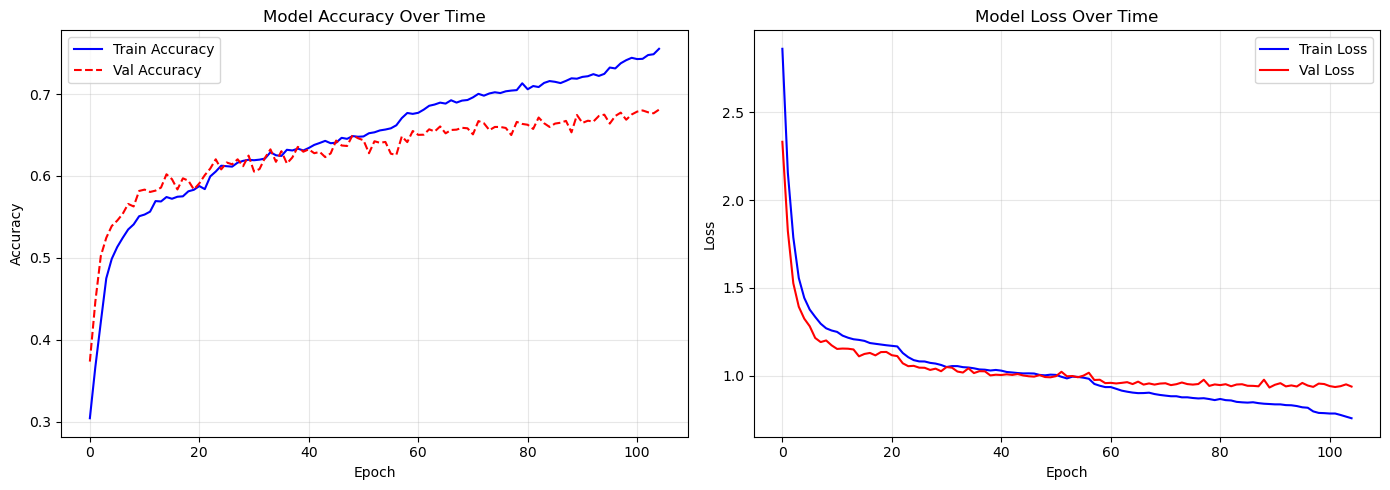

In [13]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'\n final Test Accuracy: {test_accuracy*100:.2f}%')

#Accuracy Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', color='red', linestyle='--')
ax1.set_title('Model Accuracy Over Time')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

#Loss Chart
ax2.plot(history.history['loss'], label='Train Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Val Loss', color='red')
ax2.set_title('Model Loss Over Time')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
#Get predictions
y_pred = model.predict(X_test)
y_pred_classes =  np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

153/153 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step


In [15]:
#classification report
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_))

              precision    recall  f1-score   support

       angry       0.76      0.73      0.74      1539
        fear       0.98      0.99      0.99       160
     fearful       0.56      0.44      0.49       609
       happy       0.65      0.58      0.61       769
     neutral       0.58      0.75      0.66       758
         sad       0.62      0.64      0.63       769
    surprise       0.96      0.95      0.96        80
   surprised       0.75      0.81      0.78       181

    accuracy                           0.67      4865
   macro avg       0.73      0.74      0.73      4865
weighted avg       0.68      0.67      0.67      4865



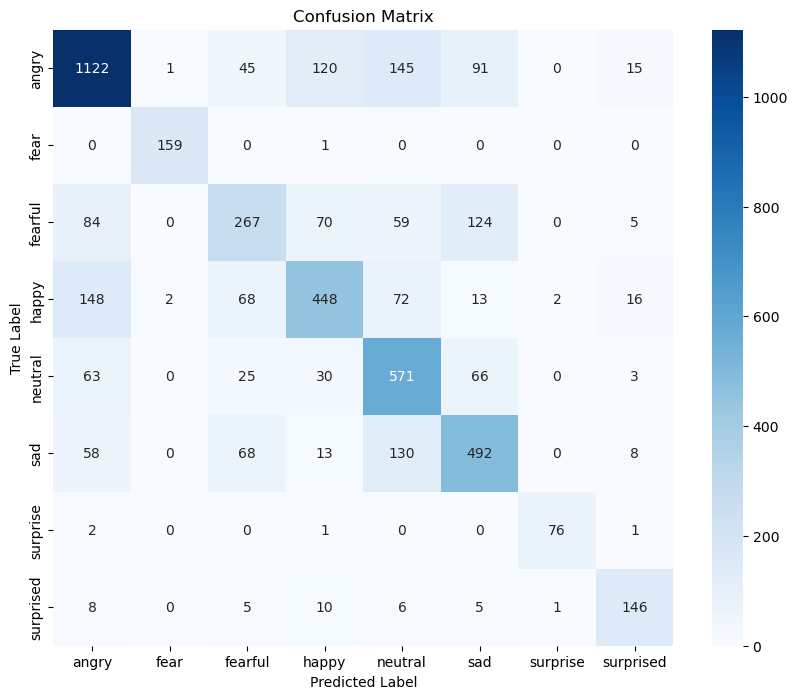

In [16]:
#confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [17]:
import joblib 

#save the trained model
model.save('emotion_model.h5')

#save the scaler and label  encoder
joblib.dump(scalar, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

print('Model, scaler and label encoder saved!')

Model, scaler and label encoder saved!
